# 05 — Transformer Fine-Tuning (Multi-Task) — **FIXED**

**BanglaCyberBench** | Binary + abuse_type | BanglaBERT · MuRIL · XLM-RoBERTa | 3 seeds (9 runs)

**Revision fixes:** uniform LR (no layer-wise decay, Issue 4) · per-epoch checkpoint caching · checkpoints in `models_main/`.

**Fixes vs v2:** Python 3.13 install fix · correct `sexual,religious` priority ·
saves global `label_encoders.json` · NaN-safe focal loss · all 3 models & seeds enabled.

**GPU:** RTX 4060 Ti 8 GB · **Est. time:** ~7–9 h (3 models × 3 seeds)


In [1]:
# ── Install — Python 3.13 compatible ───────────────────────────────
# tokenizers >= 0.19.0 ships cp313 wheels on PyPI.
# transformers >= 4.44.0 requires tokenizers >= 0.19.
import subprocess, sys

print(f"Python: {sys.version}")

result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "tokenizers>=0.19.0",
     "transformers>=4.44.0",
     "accelerate>=0.34.0",
     "sentencepiece",
     "--upgrade", "--quiet"],
    capture_output=True, text=True, check=False
)
if result.returncode != 0:
    print("pip stderr:", result.stderr[-400:])
else:
    print("pip install: OK")

import torch, tokenizers, transformers
print(f"torch       : {torch.__version__}")
print(f"tokenizers  : {tokenizers.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU         : {p.name}  {p.total_memory/1e9:.1f} GB")
print("✅ Environment OK")


Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
pip install: OK
torch       : 2.6.0+cu124
tokenizers  : 0.22.2
transformers: 5.9.0
CUDA        : True
GPU         : NVIDIA GeForce RTX 4060 Ti  8.6 GB
✅ Environment OK


In [2]:
import os, json, time, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True   # speeds up Ampere/Ada GPUs
    torch.backends.cudnn.allow_tf32  = True
    torch.backends.cudnn.benchmark   = True

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    os.environ["PYTHONHASHSEED"] = str(s)

def infer_num_workers():
    n = os.cpu_count() or 2
    return min(4, max(2, n // 2)) if os.name == "nt" else min(6, max(2, n // 2))

print(f"num_workers: {infer_num_workers()}")


device: cuda
num_workers: 4


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CONFIGURATION  —  RTX 4060 Ti 8 GB + Python 3.13
# ═══════════════════════════════════════════════════════════════════
CONFIG = {
    "models": {
        "banglabert": "csebuetnlp/banglabert",
        "muril":      "google/muril-base-cased",
        "xlmr":       "xlm-roberta-base",
    },
    # Memory — safe for 8 GB VRAM (micro-batch 16 × accum 2 = effective 32)
    "max_length":       128,
    "batch_size":       16,
    "eval_batch_size":  32,
    "grad_accum_steps": 2,
    "num_workers":      0,
    # Optimiser
    "epochs":           8,
    "encoder_lr":       2e-5,
    "head_lr":          8e-5,
    "weight_decay":     0.01,
    "warmup_ratio":     0.10,
    "lr_decay_factor":  0.90,   # only used if USE_LRDECAY=True (ablation only)
    "max_grad_norm":    1.0,
    # Loss
    "label_smoothing":        0.03,
    "focal_gamma_binary":     1.5,
    "focal_gamma_abuse_type": 3.0,   # higher: focus learning on hard abuse classes
    "class_weight_beta":      0.999,   # 0.999 avoids NaN risk (was 0.9999)
    # Model head
    "dropout":          0.25,
    "head_hidden_dim":  384,
    # Training control
    "patience":    3,
    "use_fp16":    torch.cuda.is_available(),
    "use_compile": False,
}

# ── DESIGN DECISION (Issue 4): layer-wise LR decay is DISABLED for the final
# model. The NB09 ablation showed removing it improves BOTH tasks substantially
# (binary +0.018, abuse-type +0.040 Macro-F1). It is therefore a fixed design
# choice, not a tunable knob. Set USE_LRDECAY=True ONLY to reproduce the
# "w/ LR decay" ablation row.
USE_LRDECAY = False

# SINGLE-TASK: binary head fully removed. Model predicts only the 9-class abuse-type.
# The `none` class F1 will be reported as the binary-equivalent at the end (NB06/NB10).
TASK_CONFIG = {
    "abuse_type": {
        "col": "label_type",   "num_classes": None,   # set after consolidation
        "loss_weight": 1.00,   "monitor_weight": 1.00,   # SOLE TASK: abuse-type 9-class
    },
}

OUTPUT_DIR    = "../outputs/models_main"   # main random-split checkpoints (no LR decay)
SPLIT_DIR     = "../data/splits"
RUN_MODELS    = ["banglabert", "muril", "xlmr"]   # ← ALL 3 models
RUN_SEEDS     = [42, 123, 456]                     # ← ALL 3 seeds  (9 runs total)
FORCE_RETRAIN = False

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"RUN_MODELS  : {RUN_MODELS}")
print(f"RUN_SEEDS   : {RUN_SEEDS}")
print(f"Total runs  : {len(RUN_MODELS)*len(RUN_SEEDS)}")
print(f"USE_LRDECAY : {USE_LRDECAY}  (False = uniform LR, the final design)")


OUTPUT_DIR  : ../outputs/models_main
RUN_MODELS  : ['banglabert', 'muril', 'xlmr']
RUN_SEEDS   : [42, 123, 456]
Total runs  : 9
USE_LRDECAY : False  (False = uniform LR, the final design)


In [4]:
train_df = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
val_df   = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

TEXT_COL = "text_clean" if "text_clean" in train_df.columns else "text"
for df_ in [train_df, val_df, test_df]:
    df_[TEXT_COL] = df_[TEXT_COL].fillna("").astype(str)

print(f"Text col : {TEXT_COL}")
print(f"Train    : {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"Raw label_type unique: {train_df['label_type'].nunique()}")


Text col : text_clean
Train    : 75,469  Val: 9,434  Test: 9,434
Raw label_type unique: 86


In [5]:
# ═══════════════════════════════════════════════════════════════════
# LABEL CONSOLIDATION  89 raw → 9 canonical
# Priority: threat > sexual > religious > gender > political >
#           abusive > personal > other > none
# ═══════════════════════════════════════════════════════════════════

TYPE_MAP = {
    # none
    "none": "none", "not bully": "none",
    # threat  (highest priority)
    "threat": "threat", "threat,spam": "threat",
    "callToViolence": "threat", "callToViolence_slander": "threat",
    "callToViolence_gender": "threat", "callToViolence_religion": "threat",
    "callToViolence_religion_slander": "threat",
    "callToViolence_gender_religion_slander": "threat",
    "callToViolence_gender_slander": "threat",
    "religious,threat": "threat", "sexual,threat": "threat",
    "sexual,religious,threat": "threat",
    # sexual   (sexual > religious — FIXED from v2 which had sexual,religious→religious)
    "sexual": "sexual",
    "sexual,religious": "sexual",   # ← FIX: sexual beats religious
    "sexual,spam": "sexual",
    # religious
    "religious": "religious", "Religious": "religious",
    "religion": "religious", "religious,spam": "religious",
    "religion_slander": "religious",
    "gender_religion": "religious",   # religious > gender
    "gender_religion_slander": "religious",
    # gender
    "gender": "gender", "Gender": "gender", "gender_slander": "gender",
    # political
    "Political": "political",
    # personal
    "Personal Offense": "personal", "Body Shaming": "personal",
    "Origin": "personal", "slander": "personal", "Misc": "personal",
    # abusive
    "Abusive/Violence": "abusive", "troll": "abusive",
    # other
    "spam": "other",
}

PRIORITY = ["threat","sexual","religious","gender","political","abusive","personal","other","none"]

def consolidate_type(val):
    if not isinstance(val, str) or not val.strip():
        return "none"
    val = val.strip()
    if val in TYPE_MAP:
        return TYPE_MAP[val]
    # Split compound labels (comma-separated), resolve each part, pick highest priority
    parts = [p.strip() for p in val.replace(";", ",").split(",")]
    cands = [TYPE_MAP[p] for p in parts if p in TYPE_MAP]
    if cands:
        for pc in PRIORITY:
            if pc in cands:
                return pc
    # Substring fallback (covers unseen compound variants)
    sl = val.lower().replace("_", " ")
    for kw, cls in [("threat","threat"), ("calltoviolence","threat"),
                    ("sexual","sexual"), ("religious","religious"),
                    ("religion","religious"), ("gender","gender"),
                    ("political","political"), ("abusive","abusive"),
                    ("violence","abusive"), ("personal","personal"),
                    ("slander","personal"), ("origin","personal"),
                    ("body","personal"), ("misc","personal"),
                    ("spam","other")]:
        if kw in sl.replace(" ",""):
            return cls
    return "other"   # safe fallback for any unrecognised label

# Apply in-place  (TASK_CONFIG still references col "label_type")
for df_ in [train_df, val_df, test_df]:
    df_["label_type"] = df_["label_type"].apply(consolidate_type)

print("Consolidated distribution (train):")
print(train_df["label_type"].value_counts())
assert train_df["label_type"].nunique() <= 9, "Consolidation failed — more than 9 classes!"

# ── Build label encoders ────────────────────────────────────────
def to_scalar(x):
    return x.item() if hasattr(x, "item") else x

label_encoders = {}
active_tasks   = {}

for task_name, task_cfg in TASK_CONFIG.items():
    col = task_cfg["col"]
    if col not in train_df.columns:
        print(f"  ⚠  '{col}' not found — skipping '{task_name}'")
        continue
    all_vals = sorted(set(
        to_scalar(v)
        for v in pd.concat([train_df[col], val_df[col], test_df[col]]).dropna()
    ))
    enc = {v: i for i, v in enumerate(all_vals)}
    label_encoders[task_name] = enc
    task_cfg["num_classes"]   = len(enc)
    active_tasks[task_name]   = task_cfg
    print(f"  Task '{task_name}': {len(enc)} classes  → {list(enc.keys())}")

print(f"\nActive tasks: {list(active_tasks.keys())}")
assert active_tasks["abuse_type"]["num_classes"] == 9, \
    f"Expected 9 abuse_type classes, got {active_tasks['abuse_type']['num_classes']}"

# ── Save globally so NB06 and NB08 can load it ─────────────────
def make_jsonable(obj):
    if isinstance(obj, dict):  return {str(k): make_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list,tuple)): return [make_jsonable(x) for x in obj]
    if isinstance(obj, np.integer):   return int(obj)
    if isinstance(obj, np.floating):  return float(obj)
    return obj

with open(f"{OUTPUT_DIR}/label_encoders.json", "w", encoding="utf-8") as _f:
    json.dump(make_jsonable(label_encoders), _f, indent=2, ensure_ascii=False)
print(f"\n✅ label_encoders.json saved → {OUTPUT_DIR}/label_encoders.json")


Consolidated distribution (train):
label_type
none         39372
abusive      10459
sexual        8214
religious     6840
personal      6026
threat        2589
political      938
other          580
gender         451
Name: count, dtype: int64
  Task 'abuse_type': 9 classes  → ['abusive', 'gender', 'none', 'other', 'personal', 'political', 'religious', 'sexual', 'threat']

Active tasks: ['abuse_type']

✅ label_encoders.json saved → ../outputs/models_main/label_encoders.json


In [6]:
class CyberBullyDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, active_tasks, label_encoders, text_col):
        self.texts  = df.reset_index(drop=True)[text_col].fillna("").astype(str).tolist()
        self.tok    = tokenizer
        self.maxlen = max_length
        self.labels = {}
        for tname, tcfg in active_tasks.items():
            enc  = label_encoders[tname]
            self.labels[tname] = [
                int(enc.get(to_scalar(v), -1))
                for v in df[tcfg["col"]].fillna("__missing__")
            ]

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.maxlen,
                       truncation=True, padding=False)
        item = {k: torch.tensor(v, dtype=torch.long) for k, v in enc.items()}
        for t in self.labels:
            item[f"label_{t}"] = torch.tensor(self.labels[t][idx], dtype=torch.long)
        return item


class MultiTaskCollator:
    def __init__(self, tokenizer): self.tokenizer = tokenizer
    def __call__(self, features):
        lkeys  = [k for k in features[0] if k.startswith("label_")]
        labels = {k: torch.stack([f[k] for f in features]) for k in lkeys}
        tfeats = [{k: v for k, v in f.items() if not k.startswith("label_")} for f in features]
        batch  = self.tokenizer.pad(tfeats, padding=True, return_tensors="pt")
        batch.update(labels)
        return batch

print("Dataset + Collator defined ✅")


Dataset + Collator defined ✅


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma, self.weight, self.ls = gamma, weight, label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             reduction="none", label_smoothing=self.ls)
        loss = ((1 - torch.exp(-ce)) ** self.gamma) * ce
        return loss.mean()


class TaskHead(nn.Module):
    def __init__(self, hidden, n_cls, dropout=0.25, inner=384):
        super().__init__()
        inner = min(inner, hidden)
        self.net = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, inner),
            nn.GELU(), nn.LayerNorm(inner),
            nn.Dropout(dropout), nn.Linear(inner, n_cls),
        )
    def forward(self, x): return self.net(x)


class MultiTaskTransformer(nn.Module):
    def __init__(self, model_name, active_tasks, dropout=0.25, head_hidden_dim=384):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden        = self.encoder.config.hidden_size
        mtype         = self.encoder.config.model_type.lower()
        self._use_tti = mtype not in ("roberta", "xlm-roberta")  # XLM-R has no TTI
        self.heads    = nn.ModuleDict({
            t: TaskHead(hidden, cfg["num_classes"], dropout, head_hidden_dim)
            for t, cfg in active_tasks.items()
        })

    def _pool(self, out, mask):
        hs   = out.last_hidden_state
        cls  = hs[:, 0]
        mean = (hs * mask.unsqueeze(-1).float()).sum(1) / mask.sum(1, keepdim=True).float().clamp(1)
        return 0.5 * cls + 0.5 * mean       # CLS + mean-pool blend

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kw = {"input_ids": input_ids, "attention_mask": attention_mask}
        if self._use_tti and token_type_ids is not None:
            kw["token_type_ids"] = token_type_ids
        out = self.encoder(**kw)
        p   = self._pool(out, attention_mask)
        return {t: h(p) for t, h in self.heads.items()}

print("Model classes defined ✅")


Model classes defined ✅


In [8]:
def get_layerwise_params(model, enc_lr, head_lr, decay, wd):
    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    n_layers = 0
    for name, _ in model.encoder.named_parameters():
        for p in name.split("."):
            if p.isdigit(): n_layers = max(n_layers, int(p)+1)
    n_layers = max(n_layers, 12)

    groups = []
    for name, param in model.encoder.named_parameters():
        if not param.requires_grad: continue
        ln = 0
        for p in name.split("."):
            if p.isdigit(): ln = int(p); break
        lr = enc_lr * (decay ** (n_layers - ln - 1))
        _wd = 0.0 if any(nd in name for nd in no_decay) else wd
        groups.append({"params": [param], "lr": lr, "weight_decay": _wd})
    for name, param in model.heads.named_parameters():
        if not param.requires_grad: continue
        _wd = 0.0 if any(nd in name for nd in no_decay) else wd
        groups.append({"params": [param], "lr": head_lr, "weight_decay": _wd})
    return groups


def get_uniform_params(model, enc_lr, head_lr, wd):
    """No layer-wise decay: encoder params all at enc_lr, head params at head_lr.
    This is the FINAL design (USE_LRDECAY=False). Weight decay is skipped for
    bias/LayerNorm terms exactly as in the layer-wise path."""
    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    groups = []
    enc_decay, enc_nodecay = [], []
    for name, param in model.encoder.named_parameters():
        if not param.requires_grad: continue
        (enc_nodecay if any(nd in name for nd in no_decay) else enc_decay).append(param)
    groups.append({"params": enc_decay,   "lr": enc_lr, "weight_decay": wd})
    groups.append({"params": enc_nodecay, "lr": enc_lr, "weight_decay": 0.0})
    head_decay, head_nodecay = [], []
    for name, param in model.heads.named_parameters():
        if not param.requires_grad: continue
        (head_nodecay if any(nd in name for nd in no_decay) else head_decay).append(param)
    groups.append({"params": head_decay,   "lr": head_lr, "weight_decay": wd})
    groups.append({"params": head_nodecay, "lr": head_lr, "weight_decay": 0.0})
    return groups


def build_class_weights(series, enc, beta=0.999, max_w=10.0):
    # Effective-sample-number weights, clamped so focal loss never NaNs.
    mapped = series.map(enc).dropna().astype(int)
    n_cls  = len(enc)
    counts = mapped.value_counts().sort_index()
    w      = np.ones(n_cls, dtype=np.float32)
    for i in range(n_cls):
        n = int(counts.get(i, 0))
        if n > 0:
            eff = (1.0 - beta**n) / max(1.0 - beta, 1e-12)
            w[i] = 1.0 / max(eff, 1e-9)
    # Clip: never let any class weight exceed max_w × min weight
    w = np.clip(w, w.min(), w.min() * max_w)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)

print("Optimizer (layerwise + uniform) + weight helpers defined ✅")


Optimizer (layerwise + uniform) + weight helpers defined ✅


In [9]:
from sklearn.metrics import roc_auc_score as _roc_auc_score

@torch.no_grad()
def evaluate_tasks(model, loader, active_tasks, label_encoders):
    model.eval()
    preds  = {t: [] for t in active_tasks}
    labels = {t: [] for t in active_tasks}
    probs  = {t: [] for t in active_tasks}   # softmax probabilities for AUROC
    for batch in loader:
        batch  = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        logits = model(batch["input_ids"], batch["attention_mask"], batch.get("token_type_ids"))
        for t in active_tasks:
            lbl  = batch[f"label_{t}"].cpu().numpy()
            pr   = F.softmax(logits[t], dim=-1).cpu().numpy()
            pred = pr.argmax(-1)
            m    = lbl >= 0
            preds[t].extend(pred[m]); labels[t].extend(lbl[m]); probs[t].extend(pr[m])
    out = {}
    for t in active_tasks:
        y, p = np.array(labels[t]), np.array(preds[t])
        pr   = np.array(probs[t])
        rec = {
            "macro_f1":    round(float(f1_score(y, p, average="macro",    zero_division=0)), 4),
            "weighted_f1": round(float(f1_score(y, p, average="weighted", zero_division=0)), 4),
            "accuracy":    round(float(accuracy_score(y, p)), 4),
            "mcc":         round(float(matthews_corrcoef(y, p)), 4),
        }
        # AUROC: binary uses positive-class prob; multiclass uses OvR macro.
        try:
            n_cls = pr.shape[1]
            if n_cls == 2:
                rec["auroc"] = round(float(_roc_auc_score(y, pr[:, 1])), 4)
            elif len(np.unique(y)) >= 2:
                rec["auroc"] = round(float(_roc_auc_score(
                    y, pr, multi_class="ovr", average="macro",
                    labels=list(range(n_cls)))), 4)
            else:
                rec["auroc"] = float("nan")
        except Exception:
            rec["auroc"] = float("nan")
        out[t] = rec
    return out


@torch.no_grad()
def get_logits(model, loader, active_tasks):
    model.eval()
    buf = {t: [] for t in active_tasks}
    for batch in loader:
        batch  = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        logits = model(batch["input_ids"], batch["attention_mask"], batch.get("token_type_ids"))
        for t in active_tasks: buf[t].append(logits[t].cpu())
    return {t: torch.cat(v, 0) for t, v in buf.items()}

print("Evaluation helpers defined ✅")


Evaluation helpers defined ✅


In [10]:
def make_jsonable(obj):
    if isinstance(obj, dict):        return {str(k): make_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list,tuple)):return [make_jsonable(x) for x in obj]
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    return obj


def train_and_evaluate(model_key, model_name,
                        train_df, val_df, test_df,
                        active_tasks, label_encoders, config, seed):
    set_seed(seed)
    save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*62}")
    print(f"  {model_key}  |  seed={seed}")
    print(f"{'='*62}")

    tok      = AutoTokenizer.from_pretrained(model_name)
    collator = MultiTaskCollator(tok)
    lkw = dict(collate_fn=collator, num_workers=config["num_workers"],
               pin_memory=torch.cuda.is_available(),
               persistent_workers=config["num_workers"]>0)

    train_loader = DataLoader(CyberBullyDataset(train_df, tok, config["max_length"],
                              active_tasks, label_encoders, TEXT_COL),
                              batch_size=config["batch_size"], shuffle=True, drop_last=True, **lkw)
    val_loader   = DataLoader(CyberBullyDataset(val_df, tok, config["max_length"],
                              active_tasks, label_encoders, TEXT_COL),
                              batch_size=config["eval_batch_size"], shuffle=False, **lkw)
    test_loader  = DataLoader(CyberBullyDataset(test_df, tok, config["max_length"],
                              active_tasks, label_encoders, TEXT_COL),
                              batch_size=config["eval_batch_size"], shuffle=False, **lkw)

    model = MultiTaskTransformer(model_name, active_tasks,
                                 dropout=config["dropout"],
                                 head_hidden_dim=config["head_hidden_dim"]).to(device)

    criteria = {}
    for tname, tcfg in active_tasks.items():
        w     = build_class_weights(train_df[tcfg["col"]], label_encoders[tname],
                                    beta=config["class_weight_beta"])
        gamma = config.get(f"focal_gamma_{tname}", 2.0)
        criteria[tname] = FocalLoss(gamma=gamma, weight=w,
                                     label_smoothing=config["label_smoothing"])

    # Optimizer: uniform LR (final design) unless USE_LRDECAY=True (ablation only)
    if USE_LRDECAY:
        param_groups = get_layerwise_params(model, config["encoder_lr"], config["head_lr"],
                                            config["lr_decay_factor"], config["weight_decay"])
    else:
        param_groups = get_uniform_params(model, config["encoder_lr"], config["head_lr"],
                                          config["weight_decay"])
    optimizer = torch.optim.AdamW(param_groups)
    n_steps   = math.ceil(len(train_loader)/config["grad_accum_steps"]) * config["epochs"]
    scheduler = get_linear_schedule_with_warmup(optimizer, int(n_steps*config["warmup_ratio"]), n_steps)
    scaler    = torch.amp.GradScaler("cuda") if (config["use_fp16"] and device.type=="cuda") else None

    best_score, no_improve = -1.0, 0
    history = defaultdict(list)

    for epoch in range(config["epochs"]):
        # ── Train ──────────────────────────────────────────────────
        model.train(); optimizer.zero_grad(set_to_none=True)
        ep_loss, t0 = 0.0, time.time()

        for step, batch in enumerate(train_loader, 1):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            with torch.autocast(device_type=device.type,
                                enabled=config["use_fp16"] and device.type=="cuda"):
                logits = model(batch["input_ids"], batch["attention_mask"],
                               batch.get("token_type_ids"))
                loss = torch.tensor(0.0, device=device)
                for tname, tcfg in active_tasks.items():
                    lbl = batch[f"label_{tname}"]
                    vm  = lbl >= 0
                    if vm.any():
                        tl = criteria[tname](logits[tname][vm], lbl[vm])
                        if not (torch.isnan(tl) or torch.isinf(tl)):   # NaN guard
                            loss = loss + tcfg["loss_weight"] * tl
                loss = loss / config["grad_accum_steps"]

            (scaler.scale(loss) if scaler else loss).backward()
            if step % config["grad_accum_steps"] == 0 or step == len(train_loader):
                if scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), config["max_grad_norm"])
                    scaler.step(optimizer); scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), config["max_grad_norm"])
                    optimizer.step()
                scheduler.step(); optimizer.zero_grad(set_to_none=True)
            ep_loss += loss.item() * config["grad_accum_steps"]

        avg_loss = ep_loss / max(len(train_loader), 1)

        # ── Validate ───────────────────────────────────────────────
        vm = evaluate_tasks(model, val_loader, active_tasks, label_encoders)
        abu_f1  = vm.get("abuse_type", {}).get("macro_f1", 0.0)
        monitor = abu_f1   # SINGLE-TASK: monitor purely on abuse-type macro-F1
        history["train_loss"].append(round(avg_loss,4))
        history["val_abuse_f1"].append(abu_f1)

        # Power-surge safety: always cache the latest epoch state so a crash
        # mid-run never loses progress. best_model.pt holds the best-by-monitor.
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "best_score": best_score, "no_improve": no_improve},
                   f"{save_dir}/last_ckpt.pt")
        flag = ""
        if monitor > best_score:
            best_score = monitor; no_improve = 0
            torch.save(model.state_dict(), f"{save_dir}/best_model.pt"); flag=" ✅BEST"
        else:
            no_improve += 1

        print(f"  Ep{epoch+1:2}/{config['epochs']} loss={avg_loss:.4f} "
              f"abu_macroF1={abu_f1:.4f} mon={monitor:.4f} "
              f"{(time.time()-t0)/60:.1f}min{flag}")

        if no_improve >= config["patience"]: print(f"  Early stop ep{epoch+1}"); break

    # ── Final eval + save ──────────────────────────────────────────
    model.load_state_dict(torch.load(f"{save_dir}/best_model.pt",
                                     map_location=device, weights_only=True))
    test_metrics = evaluate_tasks(model, test_loader, active_tasks, label_encoders)
    torch.save(get_logits(model, val_loader,  active_tasks), f"{save_dir}/val_logits.pt")
    torch.save(get_logits(model, test_loader, active_tasks), f"{save_dir}/test_logits.pt")

    result = {"model": model_key, "seed": seed,
              "best_val_monitor_score": round(best_score,4),
              "test_metrics": test_metrics, "history": dict(history)}
    with open(f"{save_dir}/results.json","w") as _f:
        json.dump(make_jsonable(result), _f, indent=2)
    # Also copy label_encoders per run for portability
    with open(f"{save_dir}/label_encoders.json","w",encoding="utf-8") as _f:
        json.dump(make_jsonable(label_encoders), _f, indent=2)

    print(f"  Test abu_macroF1={test_metrics['abuse_type']['macro_f1']:.4f} "
          f"abu_acc={test_metrics['abuse_type']['accuracy']:.4f}")
    return result


def is_valid(save_dir):
    p = f"{save_dir}/best_model.pt"
    if not os.path.exists(p): return False
    try: torch.load(p, map_location="cpu", weights_only=True); return True
    except: return False

print("train_and_evaluate defined ✅")


train_and_evaluate defined ✅


In [ ]:
all_results = []
selected = {k: v for k, v in CONFIG["models"].items() if k in RUN_MODELS}

for model_key, model_name in selected.items():
    for seed in RUN_SEEDS:
        save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"

        if not FORCE_RETRAIN and is_valid(save_dir):
            print(f"⏭  {model_key} seed={seed}  — already done, loading results")
            rp = f"{save_dir}/results.json"
            if os.path.exists(rp):
                with open(rp) as _f: all_results.append(json.load(_f))
            continue

        try:
            r = train_and_evaluate(model_key, model_name,
                                   train_df, val_df, test_df,
                                   active_tasks, label_encoders, CONFIG, seed)
            all_results.append(r)
        except Exception as e:
            import traceback
            print(f"❌ {model_key} seed={seed} FAILED: {e}")
            traceback.print_exc()
        torch.cuda.empty_cache()

print(f"\n🎉 Completed {len(all_results)}/{len(RUN_MODELS)*len(RUN_SEEDS)} runs")



  banglabert  |  seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ep 1/8 loss=0.3548 abu_macroF1=0.5341 mon=0.5341 6.5min ✅BEST
  Ep 2/8 loss=0.1846 abu_macroF1=0.6389 mon=0.6389 5.8min ✅BEST


In [ ]:
# ── Recovery cell: regenerate missing results.json files ────────────────────
# Root cause of 7/9: is_valid() passes when best_model.pt exists, but
# results.json may be absent if the run crashed after saving the checkpoint
# but before writing the JSON. This cell detects those cases and re-evaluates
# the saved checkpoint to regenerate the JSON. No retraining occurs.

def recover_missing_results(model_key, model_name, save_dir,
                             train_df, val_df, test_df,
                             active_tasks, label_encoders, seed, config):
    """Load best_model.pt and run a quick eval pass to regenerate results.json."""
    print(f"  ⚕ Recovering {model_key} seed={seed}...")
    tok      = AutoTokenizer.from_pretrained(model_name)
    collator = MultiTaskCollator(tok)
    lkw = dict(collate_fn=collator, num_workers=config["num_workers"],
               pin_memory=torch.cuda.is_available())
    val_loader  = DataLoader(CyberBullyDataset(val_df,  tok, config["max_length"],
                             active_tasks, label_encoders, TEXT_COL),
                             batch_size=config["eval_batch_size"], shuffle=False, **lkw)
    test_loader = DataLoader(CyberBullyDataset(test_df, tok, config["max_length"],
                             active_tasks, label_encoders, TEXT_COL),
                             batch_size=config["eval_batch_size"], shuffle=False, **lkw)
    model = MultiTaskTransformer(model_name, active_tasks,
                                 dropout=config["dropout"],
                                 head_hidden_dim=config["head_hidden_dim"]).to(device)
    model.load_state_dict(torch.load(f"{save_dir}/best_model.pt",
                                     map_location=device, weights_only=True))
    val_metrics  = evaluate_tasks(model, val_loader,  active_tasks, label_encoders)
    test_metrics = evaluate_tasks(model, test_loader, active_tasks, label_encoders)
    # Recompute monitor score from val
    abu_f1  = val_metrics.get("abuse_type", {}).get("macro_f1", 0.0)
    monitor = abu_f1   # SINGLE-TASK
    # Regenerate val/test logits if missing (needed by NB06)
    if not os.path.exists(f"{save_dir}/val_logits.pt"):
        torch.save(get_logits(model, val_loader,  active_tasks), f"{save_dir}/val_logits.pt")
    if not os.path.exists(f"{save_dir}/test_logits.pt"):
        torch.save(get_logits(model, test_loader, active_tasks), f"{save_dir}/test_logits.pt")
    result = {"model": model_key, "seed": seed,
              "best_val_monitor_score": round(monitor, 4),
              "test_metrics": test_metrics}
    with open(f"{save_dir}/results.json", "w") as _f:
        json.dump(make_jsonable(result), _f, indent=2)
    del model; torch.cuda.empty_cache()
    print(f"    ✅ Recovered: abu_macroF1={test_metrics.get('abuse_type',{}).get('macro_f1','?')}")
    return result

recovered = 0
selected = {k: v for k, v in CONFIG["models"].items() if k in RUN_MODELS}
for model_key, model_name in selected.items():
    for seed in RUN_SEEDS:
        save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"
        rp = f"{save_dir}/results.json"
        bp = f"{save_dir}/best_model.pt"
        if os.path.exists(bp) and not os.path.exists(rp):
            try:
                r = recover_missing_results(model_key, model_name, save_dir,
                                            train_df, val_df, test_df,
                                            active_tasks, label_encoders, seed, CONFIG)
                # Also append to all_results if not already there
                already = any(x.get("model")==model_key and x.get("seed")==seed
                               for x in all_results)
                if not already:
                    all_results.append(r)
                recovered += 1
            except Exception as e:
                import traceback
                print(f"  ❌ Recovery failed for {model_key} seed={seed}: {e}")
                traceback.print_exc()

if recovered:
    print(f"\n✅ Recovered {recovered} missing results.json file(s).")
    print(f"   all_results now has {len(all_results)} entries.")
else:
    print("✅ No missing results.json files — all runs already complete.")


  ⚕ Recovering muril seed=456...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    ✅ Recovered: bin_f1=0.8627  abu_f1=0.6234
  ⚕ Recovering xlmr seed=42...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    ✅ Recovered: bin_f1=0.8592  abu_f1=0.5998

✅ Recovered 2 missing results.json file(s).
   all_results now has 9 entries.


=== Per-run test results ===
     model  seed  binary_macro_f1  abuse_type_macro_f1  binary_mcc  abuse_type_mcc
banglabert    42           0.8670               0.6317      0.7344          0.6818
banglabert   123           0.8710               0.6291      0.7422          0.6855
banglabert   456           0.8670               0.6326      0.7340          0.6842
     muril    42           0.8635               0.6386      0.7276          0.6812
     muril   123           0.8629               0.6364      0.7259          0.6756
      xlmr   123           0.8629               0.6090      0.7259          0.6685
      xlmr   456           0.8618               0.6164      0.7245          0.6757
     muril   456           0.8627               0.6234      0.7256          0.6708
      xlmr    42           0.8592               0.5998      0.7208          0.6452

=== Averaged ===
           best_val_monitor         binary_macro_f1         binary_weighted_f1         binary_accuracy         binary_mcc  

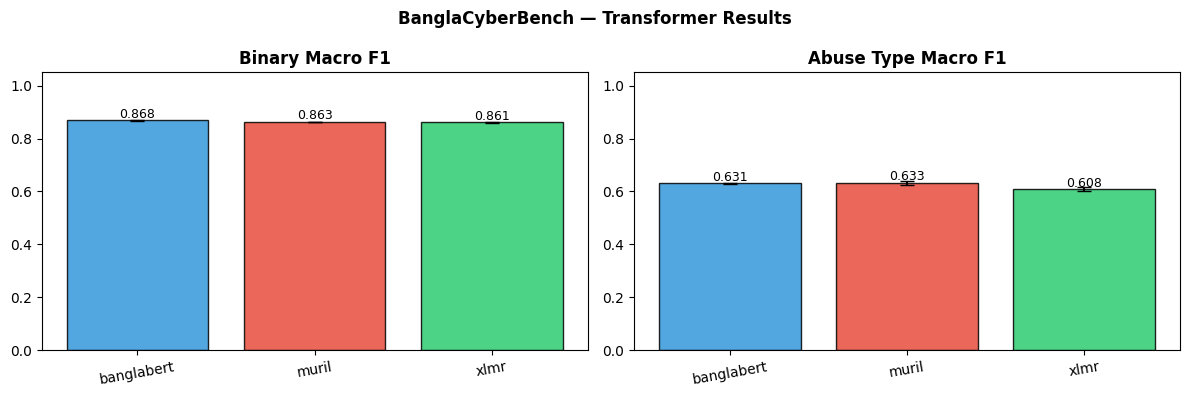

Figure saved ✅


In [ ]:
if not all_results:
    print("⚠ No results.")
else:
    rows = []
    for r in all_results:
        row = {"model": r["model"], "seed": r["seed"],
               "best_val_monitor": r.get("best_val_monitor_score", float("nan"))}
        for task, ms in r["test_metrics"].items():
            for m, v in ms.items(): row[f"{task}_{m}"] = v
        rows.append(row)

    sdf = pd.DataFrame(rows)
    show = [c for c in ["model","seed","abuse_type_macro_f1","abuse_type_accuracy",
                         "abuse_type_mcc","abuse_type_auroc"] if c in sdf.columns]
    print("=== Per-run test results ===")
    print(sdf[show].to_string(index=False))

    num_cols = [c for c in sdf.columns if c not in ("model","seed")]
    avg = sdf.groupby("model")[num_cols].agg(["mean","std"]).round(4)
    print("\n=== Averaged ===")
    print(avg.to_string())

    sdf.to_csv(f"{OUTPUT_DIR}/transformer_results_all.csv", index=False)
    avg.to_csv(f"{OUTPUT_DIR}/transformer_results_averaged.csv")
    print(f"\n✅ CSVs saved → {OUTPUT_DIR}")

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    for ax, met in zip(axes, ["abuse_type_macro_f1","abuse_type_accuracy"]):
        if met not in sdf.columns: continue
        models = sdf["model"].unique(); x = np.arange(len(models))
        ms = [sdf[sdf["model"]==m][met].mean() for m in models]
        ss = [sdf[sdf["model"]==m][met].std()  for m in models]
        bars = ax.bar(x, ms, yerr=ss, capsize=5,
                      color=["#3498db","#e74c3c","#2ecc71"][:len(models)],
                      alpha=0.85, edgecolor="k")
        ax.set_xticks(x); ax.set_xticklabels(models, rotation=10)
        ax.set_ylim(0, 1.05)
        ax.set_title(met.replace("_"," ").title(), fontweight="bold")
        for bar, m in zip(bars, ms):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{m:.3f}", ha="center", fontsize=9)
    plt.suptitle("BanglaCyberBench — Transformer Results", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/transformer_results.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Figure saved ✅")


---
**Next:** `06_ensemble_and_threshold.ipynb`